# Задача: Определение занятости парковочного места
## Тестирование обученных моделей классификации изображений

### Импорт библиотек

In [ ]:
from model import (
    create_model, evaluate_model, get_model_size_mb, set_seed
)

import json
from pathlib import Path

import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Фиксация seed для воспроизводимости эксперимента.
set_seed(42)


### Создание датасета

In [10]:
class ParkingDataset(Dataset):
    def __init__(
        self,
        image_dir,
        file_names,
        labels,
        transform=None
    ):
        self.image_dir = Path(image_dir)
        self.file_names = file_names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        image_path = self.image_dir / self.file_names[idx]

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, torch.tensor(label, dtype=torch.long)

### Функция визуализации confusion matrix

In [15]:
def plot_confusion_matrix(cm, class_names=["Free", "Occupied"], title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(6, 6))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Greens, ax=ax, colorbar=True, values_format="d")

    plt.title(title)
    plt.grid(False)
    plt.show()

### Инициализация аугментации на тестовой выборке, датасета и даталоадера 

In [ ]:
test_transform = A.Compose([
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
        max_pixel_value=255.0,
        p=1.0
    ),

    ToTensorV2()
])

with open("dataset/annotations.json") as f:
    ann = json.load(f)

test_files = ann["test"]["file_names"]
test_labels = ann["test"]["occupancy_list"]

In [13]:
test_dataset = ParkingDataset(
    image_dir="dataset/images",
    file_names=test_files,
    labels=test_labels,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

### Тестирование моделей и вывод результатов

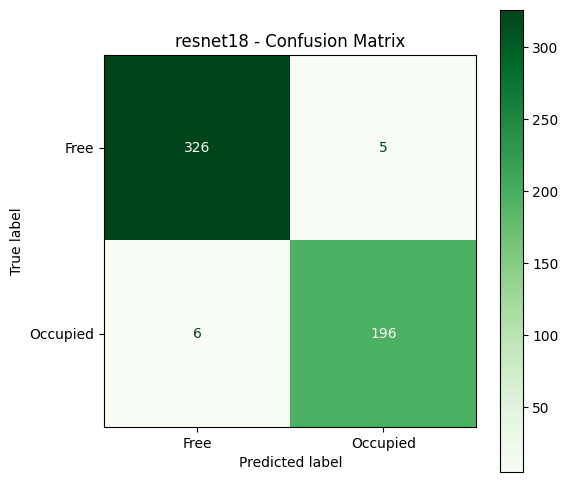

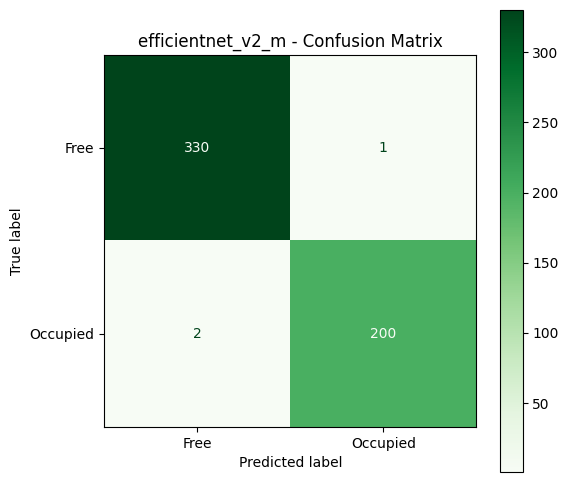

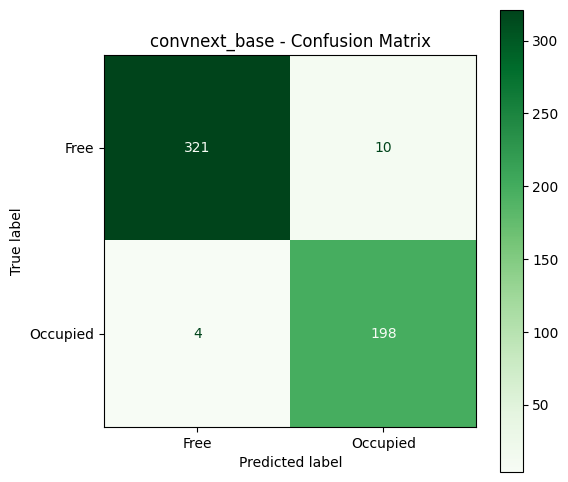

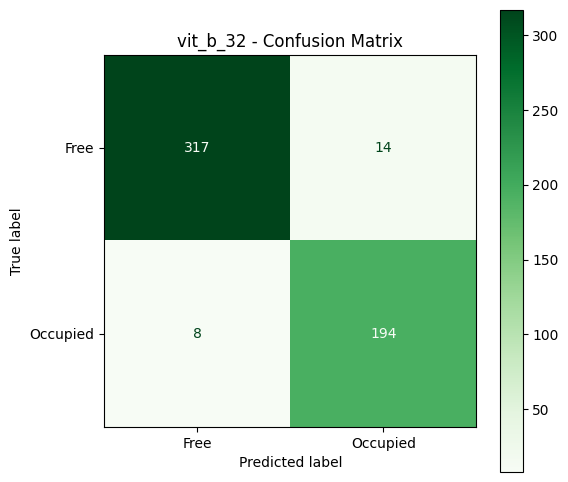

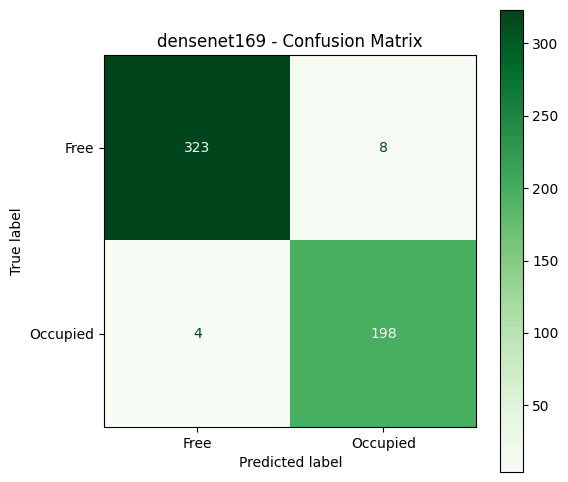

,accuracy,f1,precision,recall,time_ms
resnet18,0.979362,0.972705,0.975124,0.970297,7.983593
efficientnet_v2_m,0.994371,0.992556,0.995025,0.990099,43.389871
convnext_base,0.973734,0.965854,0.951923,0.980198,86.405773
vit_b_32,0.958724,0.946341,0.932692,0.960396,21.278349
densenet169,0.977486,0.970588,0.961165,0.980198,33.474645


In [16]:
model_names = [
    "resnet18",
    "efficientnet_v2_m",
    "convnext_base",
    "vit_b_32",
    "densenet169",
]
results = {}

for name in model_names:

    model = create_model(name)
    model.load_state_dict(torch.load(f"models/{model.__class__.__name__}.pth"))

    results[name] = evaluate_model(model, test_loader)
    results[name]["size_mb"] = get_model_size_mb(model)

    plot_confusion_matrix(
        results[name]["cm"],
        title=f"{name} - Confusion Matrix"
    )


df = pd.DataFrame({
    model: {
        "accuracy": results[model]["acc"],
        "f1": results[model]["f1"],
        "precision": results[model]["precision"],
        "recall": results[model]["recall"],
        "time_ms": results[model]["time"],
        "size_mb": results[model]["size_mb"]
    }
    for model in results
}).T

df

## **Вывод:** Наилучший результат показала модель *efficientnet_v2_m*, она и будет использована для создания приложения 